In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from random import randint

from rich.pretty import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline

from sklearn.model_selection import train_test_split

import fdl_classes as fdc

## Load dataframe

In [3]:
binary_columns_tot = ["human", "anthropic", "vegetation", "rock", "snow", "water", "zoom", "animal", "no"]
binary_columns_todrop = ["animal", "no", "water", "zoom"]
binary_columns = ["human", "anthropic", "vegetation", "rock", "snow"]
csv_raw = pd.read_csv(
    Path(".").joinpath("data").joinpath("annotations.csv")
).drop(
    binary_columns_todrop, 
    axis=1
)
csv_raw

,image,site,human,anthropic,vegetation,rock,snow
0,10057685324,Carpathians,0,1,1,0,0
1,10057694024,Carpathians,0,0,0,1,0
2,10057713565,Carpathians,0,0,1,1,0
3,10057821923,Carpathians,0,0,1,0,0
4,10067284414,Carpathians,0,0,1,0,0
...,...,...,...,...,...,...,...
2930,9697490796,Vinschgau,1,1,1,1,0
2931,9739872961,Vinschgau,0,1,1,0,0
2932,9739878607,Vinschgau,0,1,1,0,0
2933,9739881163,Vinschgau,0,0,1,0,1


In [4]:
n = 2000

rng = np.random.default_rng(42)

# ------------------------------------------------------------------ #
# Compute weights from imbalance in the original dataframe
# ------------------------------------------------------------------ #
# p = proportion of 1s; distance from 0.5 ranges from 0 (perfect balance)
# to 0.5 (all 0s or all 1s). We map it to a weight >= 1.
# weight = 1 + k * (|p - 0.5| / 0.5)  with k controlling the max weight.
k = 4  # max additional weight on top of the baseline 1
weights = {}
#print("\nAuto-computed column weights:")
for col in binary_columns:
    p = csv_raw[col].mean()
    imbalance = abs(p - 0.5) / 0.5   # 0 = perfectly balanced, 1 = fully skewed
    weights[col] = 1 + k * imbalance
    #print(f"  {col}: proportion of 1s = {p:.3f}, weight = {weights[col]:.2f}")

# ------------------------------------------------------------------ #
# Greedy balanced selection
# ------------------------------------------------------------------ #
df_shuffled = csv_raw.sample(frac=1, random_state=int(rng.integers(1e6))).reset_index(drop=True)

selected_indices = []
counts = {col: {0: 0, 1: 0} for col in binary_columns}
target_per_class = n // 2

for _, row in df_shuffled.iterrows():
    if len(selected_indices) >= n:
        break

    score = 0
    for col in binary_columns:
        w = weights[col]
        val = int(row[col])
        current = counts[col][val]
        current_opposite = counts[col][1 - val]

        if current < target_per_class:
            score += 1 * w
        elif current >= target_per_class and current_opposite < target_per_class:
            score -= 1 * w

    if score >= 0:
        selected_indices.append(row.name)
        for col in binary_columns:
            counts[col][int(row[col])] += 1

csv = df_shuffled.loc[selected_indices].reset_index(drop=True)

pd.DataFrame(data={
    "var":[col for col in binary_columns],
    "per":[csv[col].mean()*100 for col in binary_columns],
    "qtt":[sum(csv[col]) for col in binary_columns],
    "all":len(csv),
}).sort_values("per", ascending = False)



,var,per,qtt,all
2,vegetation,67.432510,1174,1741
3,rock,47.846065,833,1741
1,anthropic,46.122918,803,1741
4,snow,36.473291,635,1741
0,human,33.831132,589,1741


## Check label columns

In [5]:
pprint(csv.columns[2:])

Index(['human', 'anthropic', 'vegetation', 'rock', 'snow'], dtype='str')

## Test Dataset

In [6]:
path_to_images = Path(".").joinpath("data").joinpath("images")
path_to_images.is_dir()

True

In [7]:
dataset = fdc.FldDataset(dataframe = csv, train_mode=True,test_mode=True)

In [8]:
pprint(dataset.transform)

Compose([
  LongestMaxSize(p=1.0, area_for_downscale=None, interpolation=1, mask_interpolation=0, max_size=224, max_size_hw=None),
  PadIfNeeded(p=1.0, border_mode=0, fill=0.0, fill_mask=0.0, min_height=224, min_width=224, pad_height_divisor=None, pad_width_divisor=None, padding=0, position='center'),
  RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.15, 0.15), contrast_limit=(-0.25, 0.25), ensure_safe_range=False),
  HorizontalFlip(p=0.3),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)

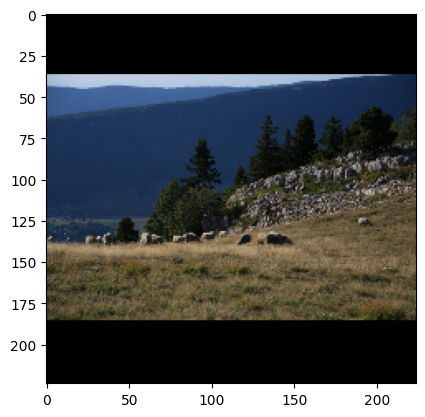

In [9]:
plt.imshow(dataset[randint(0, len(dataset) - 1)]["image"])

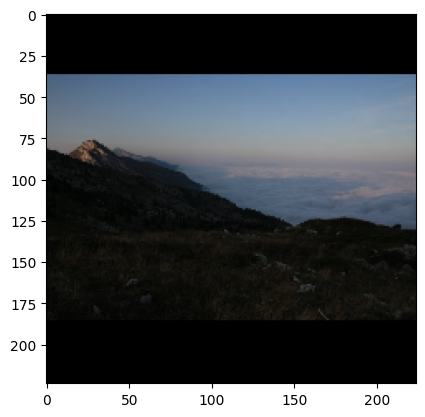

In [10]:
plt.imshow(dataset[100]["image"])

## Train

### Split dataset

In [11]:
csv_strat = csv.copy()
csv_strat["strat"] = ""
for col in csv.columns[2:]:
    print(col)
    csv_strat["strat"] += csv_strat[col].astype(str)

pprint(csv_strat.strat.value_counts())

csv_strat

human
anthropic
vegetation
rock
snow


strat
01100    213
00110    202
00100    151
00011     97
01110     90
11100     87
10011     78
01000     64
10110     58
00010     57
01101     55
00111     50
00101     48
11101     44
10100     41
11110     40
11000     39
11001     36
10101     34
10001     31
01011     27
10111     27
00001     27
11011     25
01001     22
10010     21
11111     18
01010     17
01111     16
00000     16
11010     10
Name: count, dtype: int64

,image,site,human,anthropic,vegetation,rock,snow,strat
0,13936612544,Stubai_Valley,0,1,0,1,1,01011
1,14260233257,Carpathians,0,0,1,0,1,00101
2,4901761110,Stubai_Valley,0,1,1,1,1,01111
3,2768970518,French_Alps,0,0,1,0,0,00100
4,1083809435,French_Alps,0,0,1,0,0,00100
...,...,...,...,...,...,...,...,...
1736,26055792142,Vinschgau,1,0,0,1,1,10011
1737,11244208754,Carpathians,0,0,0,0,0,00000
1738,355158630,French_Alps,1,1,1,0,1,11101
1739,4906889815,Stubai_Valley,0,1,0,1,1,01011


In [12]:
csv_strat_balanced = csv_strat.copy()
csv_strat_count = pd.DataFrame(csv_strat.strat.value_counts()).reset_index()
strat_tokeep = csv_strat_count[csv_strat_count['count'] >= 10]
csv_strat_balanced = csv_strat_balanced[csv_strat_balanced['strat'].isin(strat_tokeep['strat'])]
pprint(csv_strat_balanced.strat.value_counts())

strat
01100    213
00110    202
00100    151
00011     97
01110     90
11100     87
10011     78
01000     64
10110     58
00010     57
01101     55
00111     50
00101     48
11101     44
10100     41
11110     40
11000     39
11001     36
10101     34
10001     31
01011     27
10111     27
00001     27
11011     25
01001     22
10010     21
11111     18
01010     17
01111     16
00000     16
11010     10
Name: count, dtype: int64

In [13]:
trainval, test = train_test_split(csv_strat_balanced, test_size = 0.15, random_state = 42, stratify=csv_strat_balanced["strat"])
train, val = train_test_split(trainval, test_size = 0.18, stratify=trainval["strat"])

train = train.drop("strat", axis=1)
val = val.drop("strat", axis=1)
test = test.drop("strat", axis=1)

for n,d in [("train",train), ("val",val), ("test",test)]:
    print(n, d.shape)

train (1212, 7)
val (267, 7)
test (262, 7)


### Create model

In [14]:
model = fdc.FdlNet(
    batch_size=32,
    learning_rate=0.00001,
    max_epochs=20,
    num_workers=10,
    train=train,
    val=val,
    test=test,
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


### Create Trainer

In [15]:
trainer = fdc.get_trainer(model=model, checkpoints_path=Path("."))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/opt/python/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### Train

In [16]:
model.encoder = model.encoder.train()
trainer.fit(model)

Epoch 19/19 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38/38 0:00:19 • 0:00:00 2.22it/s v_num: 9.000 train/batch_loss:     
                                                                                0.003 train/batch_f1: 0.946        
                                                                                valid/loss: 0.015 valid/f1: 0.890  
                                                                                train/loss: 0.003 train/f1: 0.964  

`Trainer.fit` stopped: `max_epochs=20` reached.


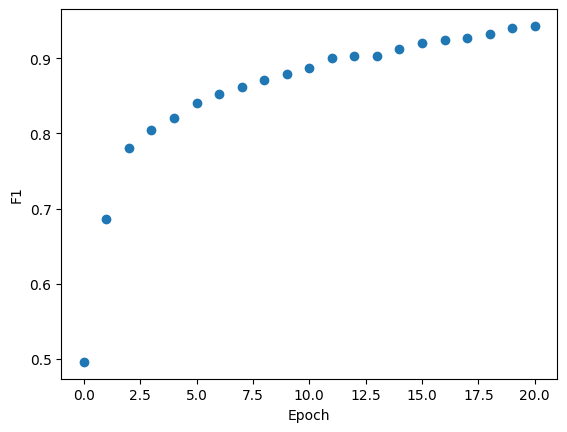

In [17]:
metrics=pd.read_csv("./lightning_logs/version_7/metrics.csv")#[["epoch","train/batch_f1","train/batch_loss","train"]]

train=metrics[["train/f1"]].dropna().reset_index(drop=True).reset_index()


plt.scatter(x=train["index"],y=train["train/f1"])
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.savefig('foo.png')

### Evaluate

In [18]:
pprint(trainer.checkpoint_callback.best_model_path)
model = fdc.FdlNet.load_from_checkpoint(
    # "./lightning_logs/version_7/checkpoints/hfswtt-val_loss=0.030-val_f1=0.00-13-train_loss=0.009-train_f1=0.903-13.ckpt",
    trainer.checkpoint_callback.best_model_path, 
    weights_only = False
)

'./lightning_logs/version_9/checkpoints/hfswtt-val_loss=0.015-val_f1=0.00-18-train_loss=0.003-train_f1=0.964-18.ckpt'

Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [19]:
model.set_thresholds()

Predicting probabilities: 100%|██████████| 9/9 [00:04<00:00,  2.08it/s]


In [20]:
data = model.classification_report_as_dict()

pd_data = {"labels": [], "precision": [], "recall": [], "f1-score": [], "support": []}
for k, v in data.items():
    pd_data["labels"].append(k)
    for c in ["precision", "recall", "f1-score", "support"]:
        pd_data[c].append(v[c])

pd.DataFrame(data=pd_data)

Predicting probabilities: 100%|██████████| 9/9 [00:04<00:00,  2.11it/s]


,labels,precision,recall,f1-score,support
0,human,0.931818,0.901099,0.916201,91.0
1,anthropic,0.879032,0.879032,0.879032,124.0
2,vegetation,0.970238,0.910615,0.939481,179.0
3,rock,0.856000,0.829457,0.842520,129.0
4,snow,0.910000,0.938144,0.923858,97.0
5,micro avg,0.912397,0.890323,0.901224,620.0
6,macro avg,0.909418,0.891669,0.900218,620.0
7,weighted avg,0.913165,0.890323,0.901356,620.0
8,samples avg,0.922784,0.904307,0.897566,620.0


### Inference

In [21]:
dir_path = path = (
            Path(".")
            .joinpath("data")
            .joinpath("images")
        ) 
print(dir_path.is_dir())
print(dir_path.resolve())

True
/home/onyxia/work/data/images


In [22]:
files = list(dir_path.glob('*.jpg'))
type(files)

list

In [23]:
dataset_inf = fdc.FldDataset(dataframe = files, train_mode=False,test_mode=False)

In [24]:
dataset_inf[1]

{'image': tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
          [-1.8044,

In [25]:
pred_inf = model.predict_labels(dataset_inf)

Predicting probabilities: 100%|██████████| 92/92 [00:23<00:00,  3.84it/s]


In [26]:
#data_pred = pd.DataFrame(data={'image':csv_raw['image']})
df_pred = pd.DataFrame(pred_inf)
df_pred.columns = binary_columns
df_pred['images'] = [p.stem for p in files]
df_pred

,human,anthropic,vegetation,rock,snow,images
0,0,0,1,1,0,9609366876
1,0,1,1,1,0,3441021098
2,1,1,0,0,1,3325754520
3,0,0,1,0,0,5847926577
4,0,1,0,1,1,8562457613
...,...,...,...,...,...,...
2930,0,0,1,0,0,5848460686
2931,0,0,1,0,1,14524681344
2932,0,0,1,1,1,4910237308
2933,0,0,1,0,1,12467758723


Predicted by model


│    human  anthropic  vegetation  rock  snow       images
580      0          1           1     1     1  26214291550

Original annotation


│   │   │   image           site  human  anthropic  vegetation  rock  snow
1826  26214291550  Stubai_Valley      0          1           1     1     0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5354247].


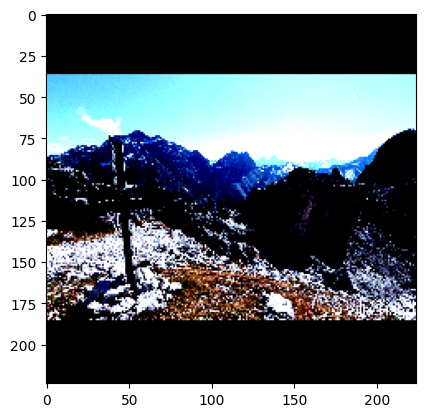

In [58]:
# Set an index among all files in the directory
n_to_show = 580
# Print what was predicted by the model for this file
print("Predicted by model")
pprint(df_pred.loc[[n_to_show]])
# Print the original data
print("Original annotation")
id_to_show = pd.to_numeric(df_pred.loc[n_to_show, "images"])
pprint(csv_raw.loc[csv_raw['image'] == id_to_show])
# Show the image
plt.imshow(dataset_inf[n_to_show]["image"].permute(1, 2, 0))
